In [4]:
%cd "C:\Users\Public\Downloads\Uni Lecture\Data Preprocessing\Final's Project\Flight Delay\src"

C:\Users\Public\Downloads\Uni Lecture\Data Preprocessing\Final's Project\Flight Delay\src


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import os, sys
from pathlib import Path
from matplotlib import pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

from src.utils.data.dataset import Dataset, to_dataset
from src.utils.utilities import *
from src.preprocessing.filler import fill_missing
from src.preprocessing.filter import quantile_boundary

In [6]:
leakage_cols = [
    'dep_time', 'dep_delay', 'dep_delay_new',

    'arr_time',

    'actual_elapsed_time', 'air_time',

    'taxi_in', 'taxi_out',
    'wheels_on', 'wheels_off',

    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]

redundant_cols = [
    'origin_state_nm',
    'origin_city_name',
    'dest_state_nm',
    'dest_city_name',
    'op_carrier_fl_num',
    'cancellation_code',
    'cancelled',
    'diverted',
    'fl_date',
    'year',
    'crs_dep_time',
    'dep_datetime',
    'weather_hour',
    'datetime'
]

# Load Data

In [7]:
'''
--LOAD DATA--
'''
print('LOADING DATA...')
RAW_PATH = Path('../data/raw/post_feat_engineer')
df = pd.read_csv(RAW_PATH / 'flight_data_2425_fe.csv', low_memory=False)
print('DONE LOADING.')
print('--------------------------------')

LOADING DATA...
DONE LOADING.
--------------------------------


# Preprocessing Pipeline

In [8]:
'''
--PREPROCESSING PIPELINE--
'''
print('--PREPROCESSING PIPELINE--')
# Basic Filter
print('BASIC FILTERING...')
df = drop_missing(df, thresh=0.3)
df = df.dropna(subset=['arr_delay'])
df = df.drop(columns=leakage_cols, errors='ignore')
df = df.drop(columns=redundant_cols, errors='ignore')

df = obj2cat(df)

ds = to_dataset(df, 'arr_delay')

# Handle Outliers
print('HANDLING OUTLIERS...')
ds = quantile_boundary(ds=ds, col='arr_delay', lower=0.001, upper=0.999)
ds = ds[~(ds.x['distance'] < 15)]
ds = ds[~((ds.x['distance'] / ds.x['crs_elapsed_time'] * 60 > 400) & (ds.x['crs_elapsed_time'] < 30))]

for col in ds.x.select_dtypes(include=['object', 'string']).columns:
    ds.x[col] = ds.x[col].astype('category')

# Handle Duplicates
print('HANDLING EXACT DUPLICATES...')
df.drop_duplicates(inplace=True)

# Fill Missing
print('FILLING MISSING...')
group = ['month', 'op_unique_carrier']
ds = fill_missing(ds, group=group)

# Split Data
print('SPLITTING DATA...')
train_ds, val_ds, test_ds = train_val_test_split(ds, random_state=21)

--PREPROCESSING PIPELINE--
BASIC FILTERING...
HANDLING OUTLIERS...
HANDLING EXACT DUPLICATES...
FILLING MISSING...


100%|██████████| 45/45 [00:02<00:00, 19.15it/s]


SPLITTING DATA...


# Feature Selection

## CatBoost Feature Importance

In [28]:
cat_cols = train_ds.x.select_dtypes(include=['category', 'str']).columns.tolist()
num_cols = train_ds.x.select_dtypes(include='number').columns.tolist()

In [21]:
for col in cat_cols:
    train_ds.x[col] = train_ds.x[col].astype(str)
    val_ds.x[col] = val_ds.x[col].astype(str)
    test_ds.x[col] = test_ds.x[col].astype(str)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=100
)

model.fit(
    train_ds.x,
    train_ds.y,
    cat_features=cat_cols,
    eval_set=(val_ds.x, val_ds.y),
    use_best_model=True
)

In [ ]:
importance = model.get_feature_importance(prettified=True)

print(importance.head(20))

## Correlation Filtering

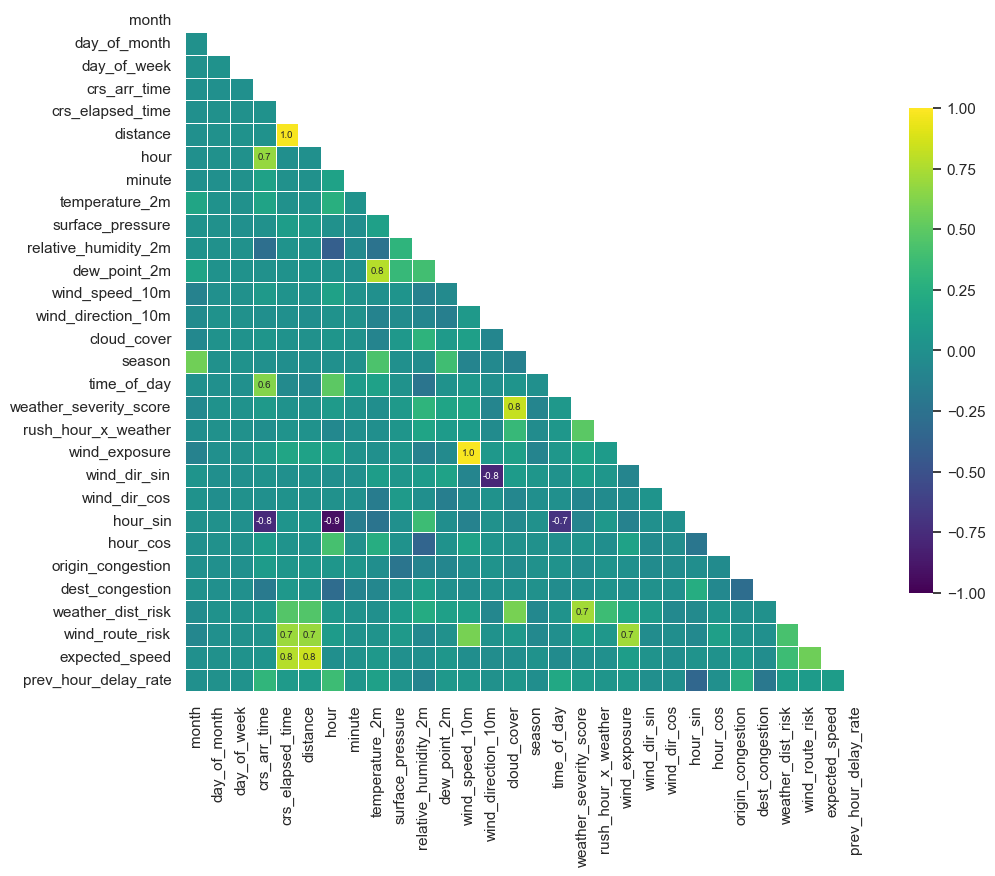

In [16]:
sns.set_theme(style='white')

Xs = train_ds.x.select_dtypes(include='number').astype('float64')
cols = Xs.columns
X_corr = np.corrcoef(Xs.to_numpy().T)# Xs.corr()
mask = np.triu(np.ones_like(X_corr, dtype=bool))
annot_matrix = np.where(np.abs(X_corr) >= 0.6, 
                        np.round(X_corr, 1).astype(str), 
                        "")

f, ax = plt.subplots(figsize=(11,9))
cmap = sns.color_palette('viridis', as_cmap=True)
sns.heatmap(X_corr,
            mask=mask,
            cmap=cmap,
            annot=annot_matrix,
            annot_kws={'fontsize':7},
            fmt="",
            xticklabels=cols,
            yticklabels=cols,
            vmax=1, vmin=-1,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .7},
            
    );

# Hyperparameter Decisions

In [28]:
cols = ['op_unique_carrier', 'origin', 'dest']
for col in cols:
    counts = df[col].value_counts(normalize=True).sort_values(ascending=False)
    cum_pct = counts.cumsum()
    print(cum_pct[-50:])

op_unique_carrier
WN    0.200902
DL    0.346103
AA    0.484708
OO    0.597321
UA    0.707990
YX    0.753448
MQ    0.794413
AS    0.829246
B6    0.862643
OH    0.895895
NK    0.928169
F9    0.956892
G4    0.974572
9E    0.988662
HA    1.000000
Name: proportion, dtype: float64
origin
SWF    0.998125
PBG    0.998198
CSG    0.998268
GTR    0.998338
HTS    0.998406
PSM    0.998469
EKO    0.998531
IAG    0.998592
DHN    0.998650
OTH    0.998708
BQK    0.998766
ITH    0.998823
TOL    0.998878
VLD    0.998933
MGW    0.998986
SPN    0.999039
EAR    0.999090
SPI    0.999142
OME    0.999193
OTZ    0.999243
BRW    0.999292
CLD    0.999338
EAU    0.999384
WYS    0.999430
HYA    0.999475
HGR    0.999518
BGM    0.999560
BIH    0.999599
ALW    0.999637
PQI    0.999672
CKB    0.999701
ALO    0.999728
SMX    0.999754
AKN    0.999779
EWN    0.999803
GUF    0.999827
STC    0.999850
ATY    0.999872
PIR    0.999893
PPG    0.999913
FMN    0.999930
LAF    0.999946
DLG    0.999962
ADK    0.999976
GST    0.9999

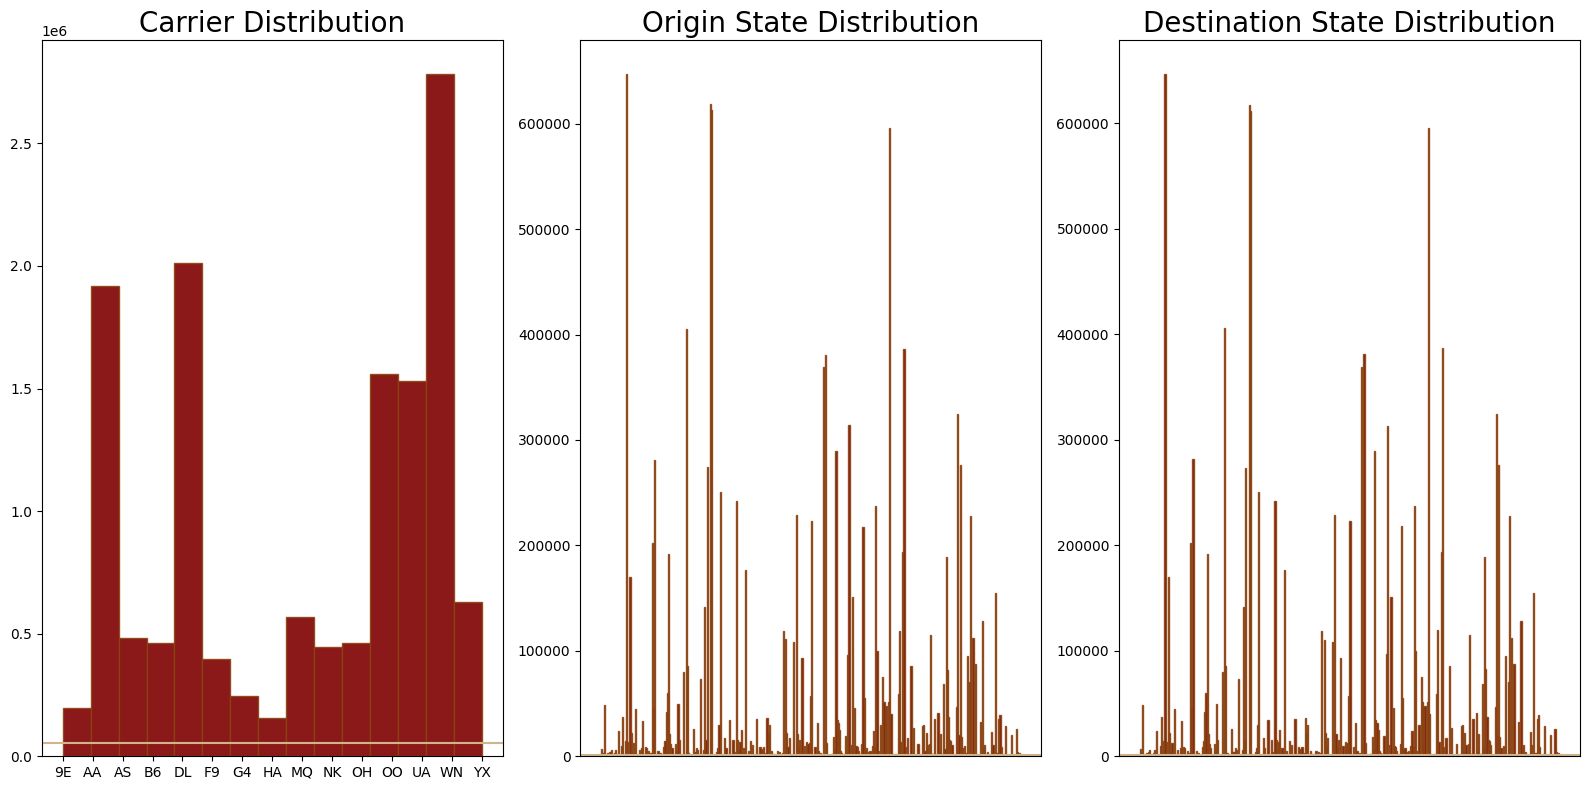

In [ ]:
fig, axes = plt.subplots(figsize=(16, 8), ncols=3, nrows=1)

op_bins = df.op_unique_carrier.nunique()
axes[0].hist(df.op_unique_carrier, bins=op_bins, alpha=0.9, color='maroon', edgecolor='saddlebrown')
axes[0].set_title('Carrier Distribution', size=20)

n_state = df.origin.nunique()
axes[1].hist(df.origin.sort_values(), bins=n_state, alpha=0.9, color='maroon', edgecolor='saddlebrown')
axes[1].set_title('Origin State Distribution', size=20)
axes[1].set_xticks([])

axes[2].hist(df.dest.sort_values(), bins=n_state, alpha=0.9, color='maroon', edgecolor='saddlebrown')
axes[2].set_title('Destination State Distribution', size=20)
axes[2].set_xticks([])

plt.tight_layout()
plt.savefig('./plot/featDistribution.png')
plt.show()

In [17]:
df['op_unique_carrier'].value_counts() <= hlines[0]

op_unique_carrier
WN    False
DL    False
AA    False
OO    False
UA    False
YX    False
MQ    False
AS    False
B6    False
OH    False
NK    False
F9    False
G4    False
9E    False
HA    False
Name: count, dtype: bool